In [1]:
x = 1+1
print(x)

import torch 
print(torch.cuda.is_available())

2
True


In [2]:
import sys
import torch
from ase import Atoms
import numpy as np
from pathlib import Path
import os
from ase.build import bulk
from ase.optimize import BFGS
from ase.visualize import view
from ase.build import graphene
from ase.build import bulk
from ase.calculators.emt import EMT
import json
from ase.io import read, write 
from ase.build import make_supercell
from ase import Atoms
import warnings 
from ase.phonons import Phonons
import matplotlib.pyplot as plt
import shutil
warnings.filterwarnings(
    "ignore",
    message=r"You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)



In [10]:
import sys
from ase import Atoms
import numpy as np
from pathlib import Path
import os
from ase.build import bulk
from ase.optimize import BFGS
from ase.visualize import view
from ase.build import graphene
from ase.build import bulk
from ase.calculators.emt import EMT
import json
from ase.io import read, write 
from ase.build import make_supercell
from ase import Atoms
import warnings 
from ase.phonons import Phonons
import matplotlib.pyplot as plt
import shutil
warnings.filterwarnings(
    "ignore",
    message=r"You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

# ———————————— PARAMETERS
material = 'hbn_c2' # could be diamond, nv_diamond, hbn, hbn_c2
# note that hbn and hbn_c2 are both bulk.
#TODO: doped - package for defects 
# complete specification of config for each material:

# TODO: set up generalised configuration using the below. 
# TODO: set up functions to use local/input arguments rather than global variables as arguments

# ————————————————————————
def place_nv_diamond(atoms):
    # 1. Grab scaled positions and symbols
    frac = atoms.get_scaled_positions(wrap=True)
    symbols = np.array(atoms.get_chemical_symbols())
    c_inds = np.where(symbols == 'C')[0]
    
    # 2. Identify the Carbon closest to the center to be our Nitrogen
    dm = frac[c_inds] - 0.5
    dm -= np.round(dm)
    n_idx = c_inds[np.argmin(np.linalg.norm(dm, axis=1))]
    
    # 3. Find its nearest neighbor to become the Vacancy
    # get_distances is much cleaner than manual norm for bulk
    dists = atoms.get_distances(n_idx, c_inds, mic=True)
    
    # Ignore the atom itself (distance 0) to find the neighbor
    dists[c_inds == n_idx] = np.inf
    v_idx = c_inds[np.argmin(dists)]
    
    # 4. Apply changes
    atoms[n_idx].symbol = 'N'
    # Use pop for the vacancy so the index shifts are handled by ASE
    atoms.pop(v_idx)
    
    print(f"NV Center: N placed at {n_idx}, Vacancy created at {v_idx}")
    return atoms

def place_cc_dimer_hbn(atoms):
    
    frac = atoms.get_scaled_positions(wrap=True)
    symbols = np.array(atoms.get_chemical_symbols())
    
    # Find the Boron closest to the fractional center (0.5, 0.5, 0.5)
    b_inds = np.where(symbols == 'B')[0]
    dm = frac[b_inds] - 0.5
    dm -= np.round(dm) # Minimum Image Convention 
    iB = b_inds[np.argmin(np.linalg.norm(dm, axis=1))]
    
    # 3. Find the closest Nitrogen in the same plane
    n_inds = np.where(symbols == 'N')[0]
    # Filter for same z-layer
    same_layer = n_inds[np.isclose(frac[n_inds, 2], frac[iB, 2], atol=1e-4)]
    
    # Find bond partner using MIC distances in Cartesian space
    d_bn = frac[same_layer] - frac[iB]
    d_bn -= np.round(d_bn)
    d_cart = d_bn @ atoms.cell
    iN = same_layer[np.argmin(np.linalg.norm(d_cart, axis=1))]
    
    # 4. Swap to Carbon
    atoms[iB].symbol = 'C'
    atoms[iN].symbol = 'C'
    
    print(f"hBN Dimer: Replaced B[{iB}] and N[{iN}]")
    return atoms

def get_material():
    # note: the current version of materials project struggles to output the primitive cell. AFLOW requires the primitive cell 
    # for its k-paths to make sense. this means that we cant rely on the MP exported poscars since they are going to be a 
    # conventional cell's unit cell, as opposed to the primitive cell. we thus construct the primitive cell in python here, for 
    # both diamond and h-BN.
    if material == 'diamond':
        atoms = bulk('C', 'diamond', a=3.567) # Pure diamond reference
        # we have a poscar file for this however it is inbuilt.
        #atoms = read(r"C:\Users\rnpla\Desktop\2026\mlip_phonons\input_files\C.poscar")
        print(atoms)
        supercell_matrix = np.diag([2,2,2])
        supercell = make_supercell(atoms, supercell_matrix)
    elif material == 'nv_diamond':
        atoms = bulk('C', 'diamond', a=3.567)
        supercell_matrix = np.diag([2,2,2])
        supercell = make_supercell(atoms, supercell_matrix)
        supercell = place_nv_diamond(supercell)
        supercell = supercell[np.argsort(supercell.get_chemical_symbols())]
    elif material == 'hbn':
        # load the unit cell from materials projet:
        # the BN.poscar was found here: 
        # https://next-gen.materialsproject.org/materials/mp-984?formula=BN
        # the materials project defaults to exporting .poscar to be read by vasp 
        atoms = read(r"/home/rnpla/projects/mlip_phonons/input_structure/BN.poscar")
        supercell_matrix = np.diag([2,2,2])
        supercell = make_supercell(atoms, supercell_matrix)
        supercell = supercell[np.argsort(supercell.get_chemical_symbols())]
    elif material == 'hbn_c2':
        atoms = read(r"/home/rnpla/projects/mlip_phonons/input_structure/BN.poscar")
        supercell_matrix = np.diag([2,2,2])
        supercell = make_supercell(atoms, supercell_matrix)
        supercell = place_cc_dimer_hbn(supercell)
        supercell = supercell[np.argsort(supercell.get_chemical_symbols())]
        # if we are dealing with monolayer version of hBN we will need the vacuum gap:
        #supercell.center(vacuum=20, axis=2) # 20 angstroms is far enough.
    else:
        raise ValueError("material not recognised")
    view(supercell)
    return atoms, supercell, supercell_matrix

atoms, supercell, supercell_matrix = get_material()

view(supercell)

if material == 'nv_diamond':
    pure_supercell = make_supercell(atoms, np.diag([2,2,2]))
    write("/home/rnpla/projects/mlip_phonons/structures/diamond_nv.poscar", supercell)
    write("/home/rnpla/projects/mlip_phonons/structures/diamond_primitive.poscar", atoms)
    write("/home/rnpla/projects/mlip_phonons/structures/diamond_super.poscar", pure_supercell)
elif material == 'hbn_c2':
    write("/home/rnpla/projects/mlip_phonons/structures/hbn_c2.poscar", supercell)
    write("/home/rnpla/projects/mlip_phonons/structures/hbn_primitive.poscar", atoms)
    write("/home/rnpla/projects/mlip_phonons/structures/hbn_super.poscar", pure_supercell)


hBN Dimer: Replaced B[20] and N[31]


In [ ]:
config = { # we assume that they provide the supercell to be analysed,
    'calculators': ['chgnet', 'pet-mad', 'orb', 'small-omat-0'], # the list of calculators to perform calculations on. #TODO: supply a full comprehensive list of every single calculator that is possible for calculations (like including various mace models as an example), this is for the user, then let the user comment out the calculators they dont want. 
    'diamond': { 
        'filepath': r'/home/rnpla/projects/mlip_phonons/structures/diamond_super.poscar',
        'relaxed': {
            'is_file_relaxed': False, # if the input file is not relaxed supply following config, if not, leave as None
            'fmax': 0.01, # maximum intermolecular force for relaxed structure
        },
        'delta': 0.01 # how far (in Å) each atom is nudged when ASE estimates second derivatives of the potential.
    },
    'nv_diamond': {
        'filepath': r'/home/rnpla/projects/mlip_phonons/structures/diamond_nv.poscar',
        'relaxed': {
            'is_file_relaxed': False, 
            'fmax': 0.01,
        },
        'delta': 0.01,
    }
    'hbn': {
        'filepath: r''
    }
        
    }
}



# ———————————— PARAMETERS
calculator = "chgnet" #"pet-mad" #"orb" #"small-omat-0" # from mace_mp
"""c
import ase
from ase.build import bulk

from orb_models.forcefield import pretrained
from orb_models.forcefield.calculator import ORBCalculator

device="cpu" # or device="cuda"
# or choose another model using ORB_PRETRAINED_MODELS[model_name]()
orbff = pretrained.orb_v3_conservative_inf_omat(
  device=device,
  precision="float32-high",   # or "float32-highest" / "float64
)
calc = ORBCalculator(orbff, device=device)
atoms = bulk('Cu', 'fcc', a=3.58, cubic=True)

atoms.calc = calc
atoms.get_potential_energy()
"""

# ————————————————————————

def get_calc_object():
    if calculator == "small-omat-0":
        from mace.calculators import mace_mp
        calc = mace_mp(model=calculator, device="cuda", default_dtype="float64")
    if calculator == "mattersim":
        from mattersim.forcefield import MatterSimCalculator
        calc = MatterSimCalculator(device="cuda")
    if calculator == "orb": 
        from orb_models.forcefield import pretrained
        from orb_models.forcefield.calculator import ORBCalculator

        device="cuda"
        # or choose another model using ORB_PRETRAINED_MODELS[model_name]()
        orbff = pretrained.orb_v3_conservative_inf_omat(
        device=device,
        precision="float32-high",   # or "float32-highest" / "float64
        )
        calc = ORBCalculator(orbff, device=device)
        print("using Orb calculator")
    if calculator == "pet-mad":
        from upet.calculator import UPETCalculator
        calc = UPETCalculator(model="pet-mad-s", version="1.1.0", device="cpu", non_conservative=True)
        print("using pet-mad calculator")
    if calculator == "chgnet":
        from chgnet.model.dynamics import CHGNetCalculator
        calc = CHGNetCalculator()
        print("using chgnet calc")
    return calc

mlip_calc = get_calc_object()
supercell.calc = mlip_calc

opt = BFGS(supercell, trajectory='defect_relax.traj') # trajectory will store the path of the optimisation if you want 
# to store that.
print(type(opt))
opt.run(fmax=0.01)  # fmax=0.01 is a good standard for phonons
print("Relaxation complete")

CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda
<class 'ase.optimize.bfgs.BFGS'>


/home/rnpla/anaconda3/envs/chgnet/lib/python3.10/site-packages/chgnet/model/model.py:898: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  volumes = torch.tensor(volumes, dtype=TORCH_DTYPE, device=atomic_numbers.device)


      Step     Time          Energy          fmax
BFGS:    0 18:15:30      -18.128181        0.000013
Relaxation complete


2
WARNING, 1 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 1.504e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.02,  0.00,  0.02) ; (omega_q = 1.124e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.03,  0.00,  0.03) ; (omega_q = 1.424e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.05,  0.00,  0.05) ; (omega_q = 1.514e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.06,  0.00,  0.06) ; (omega_q = 1.439e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.08,  0.00,  0.08) ; (omega_q = 1.178e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.09,  0.00,  0.09) ; (omega_q = 5.138e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.08,  0.08,  0.15) ; (omega_q = 5.966e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.06,  0.06,  0.13) ; (omega_q = 1.170e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.05,  0.05,  0.11) ; (omega_q = 1.439e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.04,  0.04,  0.09) ; (omega_q = 1.561e-01*i)
WARNING, 1 imaginary frequenci

/tmp/ipykernel_58828/1588203203.py:84: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  modes = np.trapz(g, E) # number of modes
/tmp/ipykernel_58828/1588203203.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{t * unit_conversion:.0f}" for t in ticks])


WARNING, 1 imaginary frequencies at q = (-0.12, -0.12, -0.12) ; (omega_q = 7.147e-02*i)
WARNING, 1 imaginary frequencies at q = (-0.12, -0.12, -0.04) ; (omega_q = 9.586e-02*i)
WARNING, 1 imaginary frequencies at q = (-0.12, -0.04, -0.12) ; (omega_q = 7.768e-02*i)
WARNING, 1 imaginary frequencies at q = (-0.12, -0.04, -0.04) ; (omega_q = 1.061e-01*i)
WARNING, 1 imaginary frequencies at q = (-0.04, -0.12, -0.12) ; (omega_q = 9.467e-02*i)
WARNING, 1 imaginary frequencies at q = (-0.04, -0.12, -0.04) ; (omega_q = 1.835e-01*i)
WARNING, 1 imaginary frequencies at q = (-0.04, -0.04, -0.12) ; (omega_q = 1.058e-01*i)
WARNING, 1 imaginary frequencies at q = (-0.04, -0.04, -0.04) ; (omega_q = 1.651e-01*i)
WARNING, 1 imaginary frequencies at q = (-0.04, -0.04,  0.04) ; (omega_q = 1.257e-01*i)
WARNING, 1 imaginary frequencies at q = (-0.04,  0.04, -0.04) ; (omega_q = 9.014e-02*i)
WARNING, 1 imaginary frequencies at q = (-0.04,  0.04,  0.04) ; (omega_q = 1.253e-01*i)
WARNING, 1 imaginary frequencies

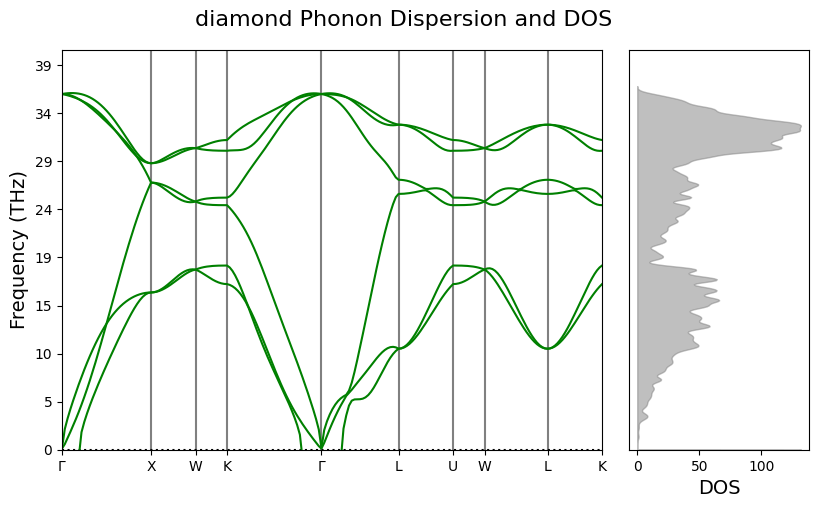

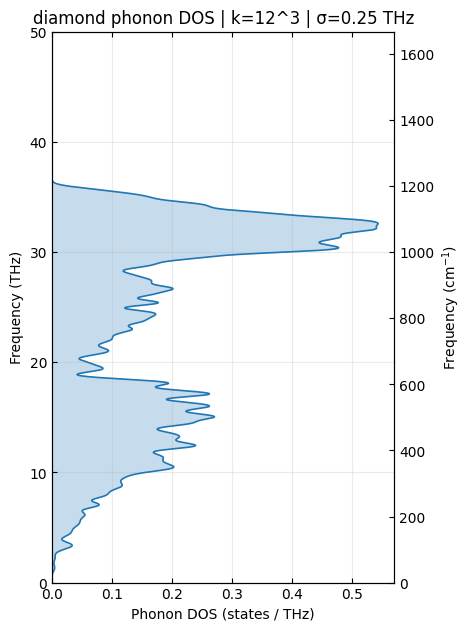

In [5]:

# ———————————— PARAMETERS
# ————————————————————————
from ase.filters import ExpCellFilter

def get_kpath():
    """
    returns the k-points and path as a string. no breaks to dentoe 
    jumps required on input. to add another material provide path and k-coordinate details
    """
    if material == 'diamond' or material == 'nv_diamond': 
        # k-point path for structure
        # AFLOW Standard Paths, taken from W. Setyawan and S. Curtarolo https://www.sciencedirect.com/science/article/pii/S0927025610002697 
        # Diamond (fcc)
        # G-X-W-K-G-L-U-W-L-K; U-X (';' is a jump)
        points = {
        'G': [0.0, 0.0, 0.0],
        'X': [0.5, 0.0, 0.5],
        'W': [0.5, 0.25, 0.75],
        'K': [0.375, 0.375, 0.75],
        'L': [0.5, 0.5, 0.5],
        'U': [0.625, 0.25, 0.625]
        } 
        k_path = "GXWKGLUWLK" # diamond
    elif material == 'hbn' or material == 'hbn_c2':
        # hBN (HEX)
        # G-M-K-G-A-L-H-A
        # this can be used for the monolayer, as that is simply GMKG
        points = {
            'G': [0.0, 0.0, 0.0],
            'M': [0.5, 0.0, 0.0],
            'K': [1/3, 1/3, 0.0],
            'A': [0.0, 0.0, 0.5],
            'L': [0.5, 0.0, 0.5],
            'H': [1/3, 1/3, 0.5]
        }
        #k_path = "GMKG" # hbn monolayer
        k_path = "GMKGALHA" # hbn bulk 
    else:
        raise ValueError
    return points, k_path

points, k_path = get_kpath()

def get_phonons():
    import numpy as np
    # clear the name from cache so 'Phonons' does not get confused.
    if os.path.exists(material):
        shutil.rmtree(material)
    print(len(supercell))
    # supercell sizing has been handled already. we want the phonons of the supercell so pass 'supercell' in. (note it is relaxed)
    # even for pure crystals, we still need a supercell because the supercell is what determines 'how big does this crystal be for which 
    # you are comfortable saying long range interactinos become insignificant?' hence we require a supercell for both pure crystals and defects.
    
    if not (supercell_matrix == np.eye(3)).all():
        size = (1, 1, 1)
    else:
        size = (2,2,2)
    mlip_calc.set(device='cuda') 
    atoms.calc = mlip_calc
    
    #ecf = ExpCellFilter(atoms)          # relax cell + positions
    #opt = BFGS(ecf, trajectory="cell_relax.traj")
    #opt.run(fmax=0.01)
    ph = Phonons(supercell, mlip_calc, supercell=size, delta=0.01, name = material)
    ph.run() # phonons object
    ph.read(acoustic=True)
    ph.clean()

    # define the k-point path. this should be relative to the unit_cell, which we stored as atoms.
    path = atoms.cell.bandpath(k_path, npoints=200, special_points=points) # bandpath 
    bs = ph.get_band_structure(path) # band_structure 
    dos = ph.get_dos(kpts=(12, 12, 12)).sample_grid(npts=400, width=1e-3) # density of states
    import numpy as np

    emin_ev = np.min(np.asarray(bs.energies))
    print("Finished getting band structure and DOS. Details:")
    print("Minimum band energy (eV):", emin_ev)
    print("Minimum frequency (THz):", emin_ev * 241.79893)

    print('Obtained DOS')
    E = np.array(dos.get_energies()) # eV
    g = np.array(dos.get_weights()) # states / eV

    modes = np.trapz(g, E) # number of modes
    print("∫DOS dE =", modes)
    print("Expected =", 3 * len(supercell)) # supercell is the atoms you passed to Phonons
    
    return ph, bs, dos, path
ph, bs, dos, path = get_phonons() # = phonons, band structure, density of states, bandpath 

def get_plot_dispersion_curve():
    if material == 'diamond' or material == 'hbn':
        # Plotting logic
        fig = plt.figure(figsize=(9, 5))

        # convert to thz 
        unit_conversion = 241.798
        emax_ev = max(
            np.max(dos.get_energies()),
            np.max(np.asarray(bs.energies))
        ) * 1.1  # 3% headroom

        # Band Structure Axis
        ax = fig.add_axes([0.12, 0.1, 0.60, 0.8])
        bs.plot(ax=ax, emin=0.0, emax=emax_ev)

        # Convert Y-ticks to THz for readability
        ticks = ax.get_yticks()
        ax.set_yticklabels([f"{t * unit_conversion:.0f}" for t in ticks])
        ax.set_ylabel("Frequency (THz)", fontsize=14)

        # DOS Axis
        dosax = fig.add_axes([0.75, 0.1, 0.20, 0.8])
        dosax.fill_between(
            dos.get_weights(),
            dos.get_energies() * unit_conversion, # Scale energies to THz
            y2=0,
            color='grey', alpha=0.5
        )

        dosax.set_ylim(0, emax_ev*unit_conversion) # Now using the THz ceilings
        dosax.set_yticks([])
        dosax.set_xlabel('DOS', fontsize=14)
        fig.suptitle(f'{material} Phonon Dispersion and DOS', fontsize=16, y = 0.98)
        fig.savefig(f'{material}_Phonon.png', dpi=300)
    else:
        pass
    pass

get_plot_dispersion_curve()

EV_TO_THz = 241.79893 # 1 eV = 241.79893 THz (E = h nu)
THz_TO_CM1 = 33.35641 # 1 THz ≈ 33.35641 cm^-1

def compute_phonon_dos(ph, kpts=(12, 12, 12), npts=4000, width_thz=0.25):
    """
    Returns (freqs_thz, dos_states_per_thz).

    ph: an ASE Phonons object AFTER ph.run() and ph.read(...)
    kpts: Monkhorst-Pack grid used for DOS integration over the BZ
    width_thz: Gaussian broadening in THz (more intuitive than eV)
    """
    width_ev = width_thz / EV_TO_THz

    dos = ph.get_dos(kpts=kpts).sample_grid(npts=npts, width=width_ev)

    energies_ev = np.asarray(dos.get_energies())
    weights_per_ev = np.asarray(dos.get_weights())

    # Convert to frequency axis
    freqs_thz = energies_ev * EV_TO_THz

    # If plotting vs THz, convert DOS units: g(ν) = g(E) * dE/dν = g(E) / (dν/dE) = g(E) / EV_TO_THz
    weights_per_thz = weights_per_ev / EV_TO_THz

    # Guard against tiny negative frequencies (numerical noise)
    mask = freqs_thz >= -1e-6
    freqs_thz = freqs_thz[mask]
    weights_per_thz = weights_per_thz[mask]
    freqs_thz = np.clip(freqs_thz, 0.0, None)

    return freqs_thz, weights_per_thz

def plot_phonon_dos(freqs_thz, dos_states_per_thz, out_png,
                    title=None, emax_thz=None, dpi=450):
    """
    High-quality single-panel DOS plot: DOS on x-axis, frequency on y-axis (THz),
    with a secondary y-axis in cm^-1.
    """
    if emax_thz is None:
        emax_thz = float(np.max(freqs_thz)) * 1.02

    fig, ax = plt.subplots(figsize=(4.6, 6.2), constrained_layout=True)

    # Curve + filled area (no explicit color set; matplotlib defaults)
    ax.plot(dos_states_per_thz, freqs_thz, linewidth=1.2)
    ax.fill_betweenx(freqs_thz, 0.0, dos_states_per_thz, alpha=0.25)

    ax.set_xlabel("Phonon DOS (states / THz)")
    ax.set_ylabel("Frequency (THz)")
    ax.set_ylim(0.0, emax_thz)
    ax.set_xlim(left=0.0)

    ax.grid(True, which="both", alpha=0.25)
    ax.tick_params(direction="in", top=True, right=True)

    if title:
        ax.set_title(title)

    # Secondary axis in cm^-1
    ax2 = ax.twinx()
    y0, y1 = ax.get_ylim()
    ax2.set_ylim(y0 * THz_TO_CM1, y1 * THz_TO_CM1)
    ax2.set_ylabel(r"Frequency (cm$^{-1}$)")
    ax2.tick_params(direction="in", top=True, right=True)

    fig.savefig(out_png, dpi=dpi)
    
freqs_thz, g_thz = compute_phonon_dos(ph, kpts=(12,12,12), npts=5000, width_thz=0.25)
plot_phonon_dos(freqs_thz, g_thz,
                out_png=f"{material}_DOS.png",
                title=f"{material} phonon DOS | k={12}^3 | σ=0.25 THz",
                emax_thz=50.0)






WARNING, 2 imaginary frequencies at q = (-0.04,  0.04, -0.46) ; (omega_q = 2.304e-01*i)
WARNING, 2 imaginary frequencies at q = (-0.04,  0.04, -0.38) ; (omega_q = 2.321e-01*i)
WARNING, 2 imaginary frequencies at q = (-0.04,  0.04, -0.29) ; (omega_q = 2.342e-01*i)
WARNING, 2 imaginary frequencies at q = (-0.04,  0.04, -0.21) ; (omega_q = 2.363e-01*i)
WARNING, 2 imaginary frequencies at q = (-0.04,  0.04, -0.12) ; (omega_q = 2.379e-01*i)
WARNING, 2 imaginary frequencies at q = (-0.04,  0.04, -0.04) ; (omega_q = 2.388e-01*i)
WARNING, 2 imaginary frequencies at q = (-0.04,  0.04,  0.04) ; (omega_q = 2.388e-01*i)
WARNING, 2 imaginary frequencies at q = (-0.04,  0.04,  0.12) ; (omega_q = 2.379e-01*i)
WARNING, 2 imaginary frequencies at q = (-0.04,  0.04,  0.21) ; (omega_q = 2.363e-01*i)
WARNING, 2 imaginary frequencies at q = (-0.04,  0.04,  0.29) ; (omega_q = 2.342e-01*i)
WARNING, 2 imaginary frequencies at q = (-0.04,  0.04,  0.38) ; (omega_q = 2.321e-01*i)
WARNING, 2 imaginary frequencies